In [6]:
# =====================================================================
# DUAL-DOMAIN MENTAL HEALTH RISK INTELLIGENCE SYSTEM
# Single Complete Execution Notebook
# =====================================================================

import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Preprocessing & Models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

# Explainability
import shap

# Configure Visual Settings
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

print("✅ Imports complete.")

✅ Imports complete.


d:\mlpa_lab\mental-health-risk-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [1]:
import sys
import os

# Add project root directory to Python path
sys.path.append(os.path.abspath(".."))

# Now import will succeed
from src.preprocessing import clean_workplace_data, clean_student_data

df_work_clean = clean_workplace_data("../data/raw/survey.csv")
df_stud_clean = clean_student_data("../data/raw/Student Mental Health Analysis During Online Learning.csv")

print("✅ Preprocessing functions imported successfully!")
print("Workplace Data Shape:", df_work_clean.shape)
print("Student Data Shape  :", df_stud_clean.shape)

✅ Preprocessing functions imported successfully!
Workplace Data Shape: (1259, 28)
Student Data Shape  : (1000, 11)


d:\mlpa_lab\mental-health-risk-prediction\src\preprocessing.py:16: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Age'].fillna(df['Age'].median(), inplace=True)



  SECTION 1: WORKPLACE MODEL PIPELINE (survey.csv)  
Loaded survey.csv: (1259, 27)


C:\Users\HP\AppData\Local\Temp\ipykernel_14504\603053018.py:18: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_work['Age'].fillna(df_work['Age'].median(), inplace=True)


Workplace Accuracy  : 0.7341
Workplace Recall    : 0.7031
Workplace ROC-AUC   : 0.7885


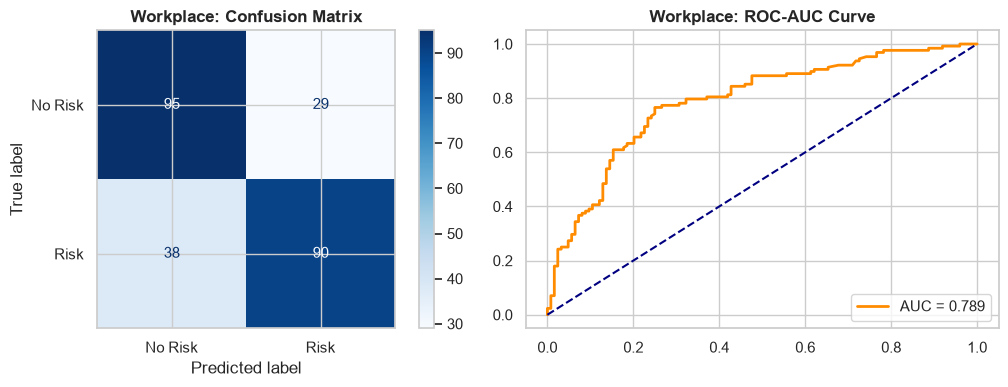

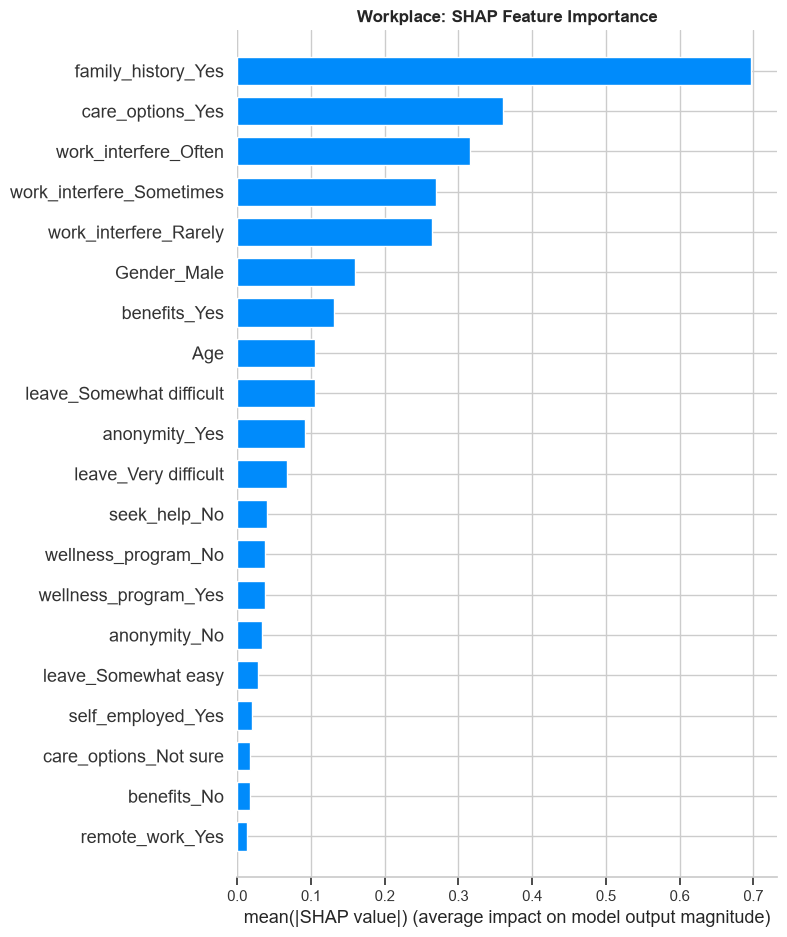

In [2]:
# =====================================================================
# SECTION 1: WORKPLACE MODEL PIPELINE (survey.csv)
# =====================================================================
print("\n" + "="*60)
print("  SECTION 1: WORKPLACE MODEL PIPELINE (survey.csv)  ")
print("="*60)

# Load Dataset
workplace_path = "../data/raw/survey.csv"
if not os.path.exists(workplace_path):
    workplace_path = "survey.csv" # Fallback if run from root directory

df_work = pd.read_csv(workplace_path)
print(f"Loaded survey.csv: {df_work.shape}")

# Data Cleaning
df_work['Age'] = df_work['Age'].apply(lambda x: np.nan if (x < 18 or x > 80) else x)
df_work['Age'].fillna(df_work['Age'].median(), inplace=True)

def clean_gender(gender_str):
    if pd.isna(gender_str): return 'Other'
    g = str(gender_str).lower().strip()
    if g in ['male', 'm', 'male-ish', 'maile', 'cis male', 'mal', 'male (cis)', 'make', 'guy (-ish) ^_^', 'male ', 'man', 'msle', 'mail', 'cis man', 'malr']:
        return 'Male'
    elif g in ['female', 'f', 'cis female', 'woman', 'femake', 'female ', 'cis-female/femme', 'female (cis)', 'femail']:
        return 'Female'
    else:
        return 'Other'

df_work['Gender'] = df_work['Gender'].apply(clean_gender)
df_work['target'] = df_work['treatment'].map({'Yes': 1, 'No': 0})

workplace_features = [
    'Age', 'Gender', 'self_employed', 'family_history', 'remote_work', 
    'tech_company', 'benefits', 'care_options', 'wellness_program', 
    'seek_help', 'anonymity', 'leave', 'work_interfere'
]

X_work = df_work[workplace_features]
y_work = df_work['target']

X_work_train, X_work_test, y_work_train, y_work_test = train_test_split(
    X_work, y_work, test_size=0.2, random_state=42, stratify=y_work
)

# Pipeline Transformers
num_work_cols = ['Age']
cat_work_cols = [c for c in workplace_features if c != 'Age']

preprocessor_work = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_work_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))]), cat_work_cols)
])

X_work_train_proc = preprocessor_work.fit_transform(X_work_train)
X_work_test_proc = preprocessor_work.transform(X_work_test)

work_feature_names = num_work_cols + list(preprocessor_work.named_transformers_['cat']['encoder'].get_feature_names_out(cat_work_cols))
X_work_train_df = pd.DataFrame(X_work_train_proc, columns=work_feature_names)
X_work_test_df = pd.DataFrame(X_work_test_proc, columns=work_feature_names)

# Train XGBoost Model
model_work = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, eval_metric='logloss', random_state=42)
model_work.fit(X_work_train_df, y_work_train)

# Evaluation
y_work_pred = model_work.predict(X_work_test_df)
y_work_probs = model_work.predict_proba(X_work_test_df)[:, 1]

print(f"Workplace Accuracy  : {accuracy_score(y_work_test, y_work_pred):.4f}")
print(f"Workplace Recall    : {recall_score(y_work_test, y_work_pred):.4f}")
print(f"Workplace ROC-AUC   : {roc_auc_score(y_work_test, y_work_probs):.4f}")

# Plot Workplace Confusion Matrix & ROC
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay(confusion_matrix(y_work_test, y_work_pred), display_labels=['No Risk', 'Risk']).plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Workplace: Confusion Matrix', fontweight='bold')

fpr, tpr, _ = roc_curve(y_work_test, y_work_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc_score(y_work_test, y_work_probs):.3f}')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_title('Workplace: ROC-AUC Curve', fontweight='bold')
axes[1].legend(loc='lower right')
plt.tight_layout()
plt.show()

# SHAP Explainability
explainer_work = shap.TreeExplainer(model_work)
shap_work = explainer_work(X_work_test_df)
plt.figure(figsize=(8, 4))
shap.summary_plot(shap_work, X_work_test_df, plot_type="bar", show=False)
plt.title("Workplace: SHAP Feature Importance", fontweight='bold')
plt.tight_layout()
plt.show()


In [9]:
pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.6-py3-none-any.whl.metadata (22 kB)
Using cached imbalanced_learn-0.14.2-py3-none-any.whl (236 kB)
Using cached sklearn_compat-0.1.6-py3-none-any.whl (22 kB)

   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



  SECTION 2: ACADEMIC MODEL PIPELINE (Student Dataset)  
Loaded Student Dataset: (1000, 10)

--- Academic Multi-Class Evaluation Metrics ---
Academic Accuracy  : 0.3800
Academic Precision : 0.3937
Academic Recall    : 0.3800
Academic F1-Score  : 0.3846
Academic ROC-AUC   : 0.4943


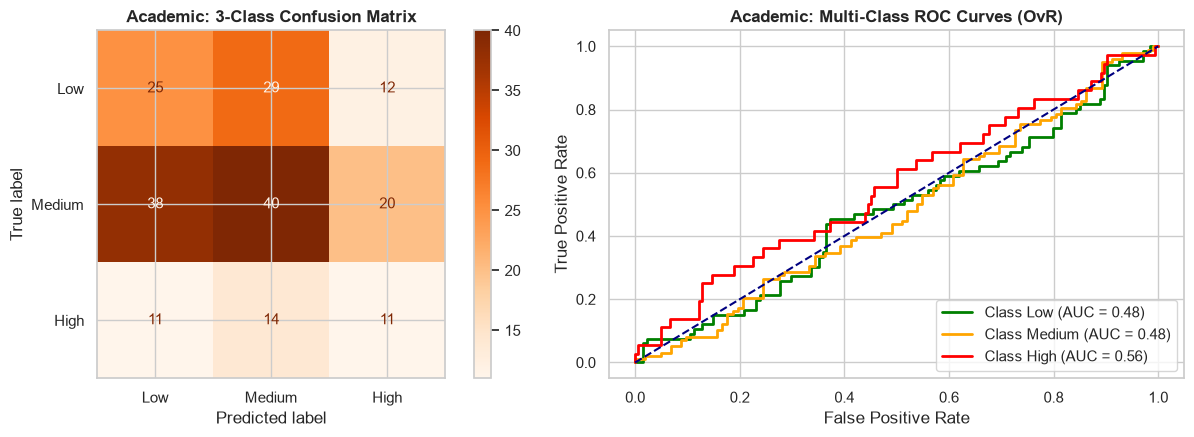

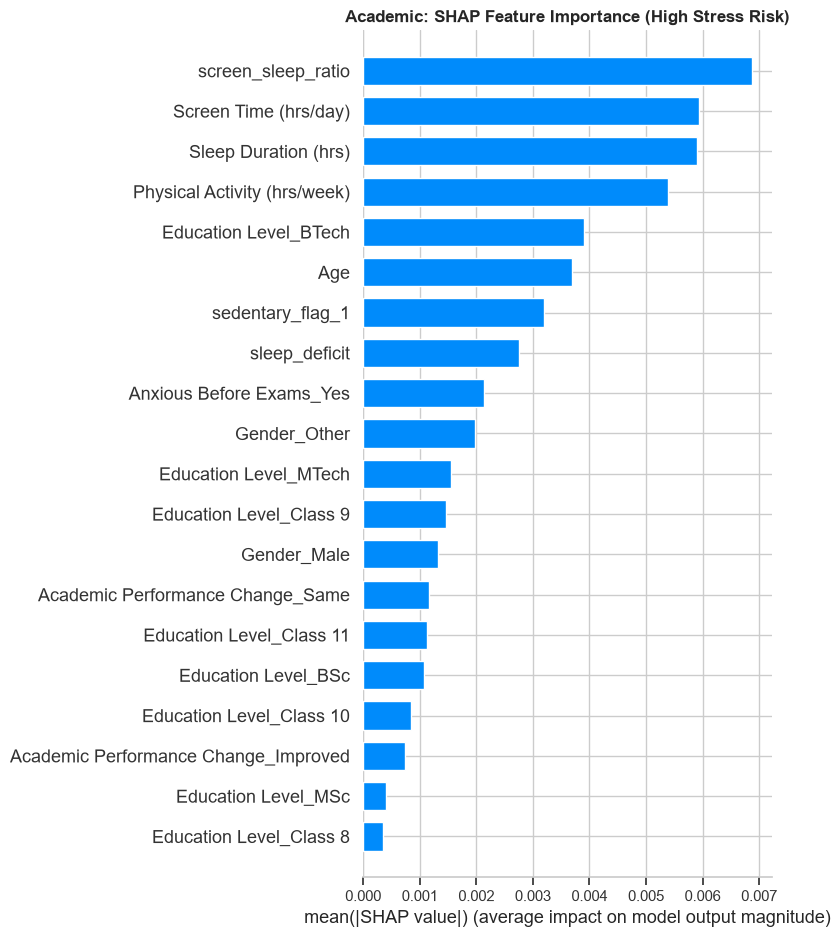

In [11]:
# =====================================================================
# SECTION 2: ACADEMIC MODEL PIPELINE (Student Dataset - Multi-Class)
# =====================================================================
import os
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

print("\n" + "="*60)
print("  SECTION 2: ACADEMIC MODEL PIPELINE (Student Dataset)  ")
print("="*60)

student_path = "../data/raw/Student Mental Health Analysis During Online Learning.csv"
if not os.path.exists(student_path):
    student_path = "Student Mental Health Analysis During Online Learning.csv"

df_student = pd.read_csv(student_path)
print(f"Loaded Student Dataset: {df_student.shape}")

# 1. Feature Engineering
df_student['screen_sleep_ratio'] = df_student['Screen Time (hrs/day)'] / (df_student['Sleep Duration (hrs)'] + 1e-5)
df_student['sleep_deficit'] = (8.0 - df_student['Sleep Duration (hrs)']).clip(lower=0)
df_student['sedentary_flag'] = ((df_student['Physical Activity (hrs/week)'] < 2) & (df_student['Screen Time (hrs/day)'] > 6)).astype(int)

# Multi-Class Target Mapping (Low: 0, Medium: 1, High: 2)
df_student['target'] = df_student['Stress Level'].map({'Low': 0, 'Medium': 1, 'High': 2})

# ADD ALL ENGINEERED FEATURES TO FEATURE LIST
student_features = [
    'Gender', 'Age', 'Education Level', 'Screen Time (hrs/day)', 
    'Sleep Duration (hrs)', 'Physical Activity (hrs/week)', 
    'Anxious Before Exams', 'Academic Performance Change',
    'screen_sleep_ratio', 'sleep_deficit', 'sedentary_flag'
]

X_student = df_student[student_features]
y_student = df_student['target']

# 2. Train-Test Split
X_stud_train, X_stud_test, y_stud_train, y_stud_test = train_test_split(
    X_student, y_student, test_size=0.2, random_state=42, stratify=y_student
)

num_stud_cols = ['Age', 'Screen Time (hrs/day)', 'Sleep Duration (hrs)', 'Physical Activity (hrs/week)', 'screen_sleep_ratio', 'sleep_deficit']
cat_stud_cols = ['Gender', 'Education Level', 'Anxious Before Exams', 'Academic Performance Change', 'sedentary_flag']

# Preprocessing Pipeline
preprocessor_stud = ColumnTransformer([
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_stud_cols),
    ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))]), cat_stud_cols)
])

X_stud_train_proc = preprocessor_stud.fit_transform(X_stud_train)
X_stud_test_proc = preprocessor_stud.transform(X_stud_test)

stud_feature_names = num_stud_cols + list(preprocessor_stud.named_transformers_['cat']['encoder'].get_feature_names_out(cat_stud_cols))
X_stud_train_df = pd.DataFrame(X_stud_train_proc, columns=stud_feature_names)
X_stud_test_df = pd.DataFrame(X_stud_test_proc, columns=stud_feature_names)

# 3. Balanced Model Training (Single Fit with Class Weights)
model_student = RandomForestClassifier(
    n_estimators=100,
    max_depth=3,
    class_weight='balanced', # Automatically handles class imbalance natively
    random_state=42
)
model_student.fit(X_stud_train_df, y_stud_train)

# 4. Predictions & Probability Calculations
y_stud_pred = model_student.predict(X_stud_test_df)
y_stud_probs = model_student.predict_proba(X_stud_test_df)

# 5. Evaluation Metrics
acc_stud = accuracy_score(y_stud_test, y_stud_pred)
prec_stud = precision_score(y_stud_test, y_stud_pred, average='weighted', zero_division=0)
rec_stud = recall_score(y_stud_test, y_stud_pred, average='weighted')
f1_stud = f1_score(y_stud_test, y_stud_pred, average='weighted')
auc_stud = roc_auc_score(y_stud_test, y_stud_probs, multi_class='ovr', average='weighted')

print("\n--- Academic Multi-Class Evaluation Metrics ---")
print(f"Academic Accuracy  : {acc_stud:.4f}")
print(f"Academic Precision : {prec_stud:.4f}")
print(f"Academic Recall    : {rec_stud:.4f}")
print(f"Academic F1-Score  : {f1_stud:.4f}")
print(f"Academic ROC-AUC   : {auc_stud:.4f}")

# 6. Visualizations
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Confusion Matrix
cm_stud = confusion_matrix(y_stud_test, y_stud_pred)
ConfusionMatrixDisplay(cm_stud, display_labels=['Low', 'Medium', 'High']).plot(ax=axes[0], cmap='Oranges')
axes[0].set_title('Academic: 3-Class Confusion Matrix', fontweight='bold')

# ROC-AUC Curves
y_test_bin = label_binarize(y_stud_test, classes=[0, 1, 2])
class_names = ['Low', 'Medium', 'High']
colors = ['green', 'orange', 'red']

for i in range(3):
    fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_stud_probs[:, i])
    auc_i = roc_auc_score(y_test_bin[:, i], y_stud_probs[:, i])
    axes[1].plot(fpr_i, tpr_i, color=colors[i], lw=2, label=f'Class {class_names[i]} (AUC = {auc_i:.2f})')

axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--')
axes[1].set_title('Academic: Multi-Class ROC Curves (OvR)', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

# 7. SHAP Explainability
explainer_stud = shap.TreeExplainer(model_student)
shap_stud = explainer_stud(X_stud_test_df)

plt.figure(figsize=(9, 4))
shap.summary_plot(shap_stud[:, :, 2], X_stud_test_df, plot_type="bar", show=False)
plt.title("Academic: SHAP Feature Importance (High Stress Risk)", fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
import sys
import os

# Add project root directory to Python path
sys.path.append(os.path.abspath(".."))

# Now Python can locate the 'src' folder
from src.preprocessing import clean_workplace_data, clean_student_data

ImportError: cannot import name 'clean_workplace_data' from 'src.preprocessing' (d:\mlpa_lab\mental-health-risk-prediction\src\preprocessing.py)